# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Leann Vo

**Date:** 9/2/2026

In [160]:
# #1: Cleaning Price Variable

# Load the airbnb data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./airbnb_hw.csv')

# Look at the data
print("df.shape: num rows, col")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes['Price'], '\n')
# Price was object dtype, needs to be cleaned/changed to numerical

# Diagnose dirty variable
var = 'Price'
print(df[var].unique(), '\n')

# Prices above 999 have commas that need to be cleaned

df.shape: num rows, col
(30478, 13) 

df.dtypes:
object 

['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1,990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '289' '179' '98' '195' '29' '27' '39'
 '249' '192' '142' '169' '1,000' '131' '138' '113' '122' '329' '101' '475'
 '238' '272' '308' '126' '235' '315' '248' '128' '56' '207' '450' '215'
 '210' '385' '445' '136' '247' '118' '77' '76' '92' '198' '205' '299'
 '222' '245' '104' '153' '349' '114' '320' '292' '226' '420' '500' '325'
 '307' '78' '265' '108' '123' '189' '32' '58' '86' '219' '800' '335' '63'
 '229' '425' '67' '87' '1,200' '158' '650' '234' '310' '695' '400' 

In [161]:
# Clean numerical variable
print('Before coercion:\n', df[var].describe(), '\n')
df[var] = df[var].str.replace(',', '') # removes commas
df[var] = pd.to_numeric(df[var], errors='coerce') # changes to numeric
df['Price_nan'] = df[var].isnull()
print('After coercion:\n', df[var].describe(), '\n')
print('Total missings:\n', sum(df['Price_nan']))
print(df[var].unique(), '\n')

# I ended up with 0 missing values. I removed the commas from the Price values that were above 999 and converted the column from object to numeric.

Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total missings:
 0
[  145    37    28   199   549   149   250    90   270   290   170    59
    49    68   285    75   100   150   700   125   175    40    89    95
    99   499   120    79   110   180   143   230   350   135    85    60
    70    55    44   200   165   115    74    84   129    50   185    80
   190   140    45    65   225   600   109  1990    73   240    72   105
   155   160    42   132   117   295   280   159   107    69   239   220
   399   130   375   585   275   139   260    35   133   300   289   179
    98   195    29    27    39   249   192   142   169  1000   131   138
   113   122   329   101   475   238   272   308   126   235   

In [162]:
# #2: Minnesota Data Variables
df = pd.read_csv('./mn_police_use_of_force.csv')

# Look at the data
print("df.shape: num rows, col")
print(df.shape, '\n')

print("df.dtypes: col types")
print(df.dtypes, '\n')

df.head()

# Diagnose dirty variable
var = 'subject_injury'
print(df[var].unique(), '\n') # need to fix nan
print(df[var].value_counts(), '\n')

df.shape: num rows, col
(12925, 13) 

df.dtypes: col types
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 



In [163]:
# Clean Categorical variable
df[var] = df[var].replace('', np.nan)
# print(df[var].unique(), '\n')
# print(df[var].value_counts(dropna=False), '\n')

df_cleaned = df.dropna(subset=[var])
# print(df_cleaned[var].unique(), '\n')

# df_cleaned.head()

# Count missing values
print('Missing values:', df[var].isnull().sum())

# print('Missing values after cleaning:', df_cleaned[var].isnull().sum())

# Find proportion of missing values
missing_val = df[var].isnull().mean()
print('Proportion missing:', missing_val)
# print('Percent missing:', missing_val*100)

# Cross-tabulate subject_injury and force_type
cross_tab = pd.crosstab(df['subject_injury'], df['force_type'],dropna=False)
# print(cross_tab)
cross_tab_prop = cross_tab / cross_tab.sum(axis=0)
# print(cross_tab_prop)

Missing values: 9848
Proportion missing: 0.7619342359767892


About 76.2% of the subject_injury values were missing. This is definitely a concern since over half of the data doesn't have any injury information. Using the cross-tab, I found that the majority of missing values varied based on the force type. Bodily Force, Taser, and Chemical Irritant cases have at least 70% missing subject_injury values while other force types have far less.



**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

In [164]:
# 1. Open file
df = pd.read_excel('./GSAF5.xls')

# Look at data
print(df.head())

           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age  ...                    Species   \
0   Unknown Female   F   ?  ...                

In [165]:
# 2. Drop columns with no data in every row
df_cleaned = df.loc[:, :'Source'] # All columns Date - Source were kept
print(df_cleaned.head())

           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age                                      Injury  \
0   Unknown Female   F   ?          

[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914. 1913. 1912. 1911. 1910. 1909.
 1908. 1907. 1906. 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1897.
 1896. 1895. 1894. 1893. 1892. 1891. 1890. 1889. 1888. 1887. 1886. 1885.
 1884. 1883. 1882. 1881. 1880. 1879. 1878. 1877. 1876. 1875. 1874. 1873.
 1872. 1871. 1870. 1869. 1868. 1867. 1866. 1865. 18

<Axes: xlabel='Year'>

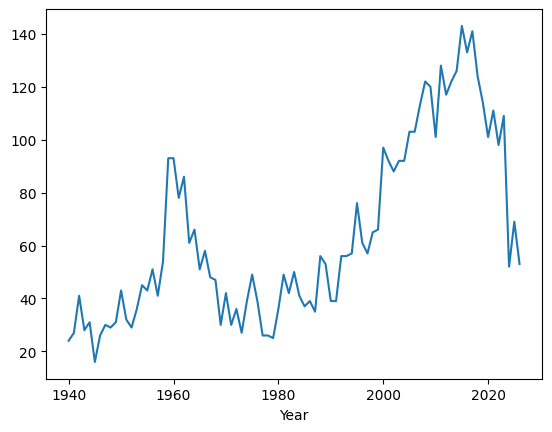

In [166]:
# 3. Look at year variable
print(df_cleaned['Year'].unique())
print(df_cleaned['Year'].dtype) # stored as float64

df_since1940 = df_cleaned[df_cleaned['Year'] >= 1940]
print(df_since1940['Year'].unique())
# Count amount of counts each year
attacks_per_year = df_since1940['Year'].value_counts().sort_index() # Counts attacks in chrono order
attacks_per_year.plot() # Better visualization of data, shows increasing from 1980-2015

The years range from 0 to 2026 with at least one missing value and a couple very old years that are less than 100. The attacks had a spike around 1960 and then steadily increased from around 1980 to 2015. Since around 2015, we have seen a decrease in shark attacks.


[nan 43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 19. 11. 20. 38. 39. 16. 22.
 55. 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85. 18. 66.
 37. 42. 45. 30. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65. 64.
 32. 10. 62. 52. 44. 47. 59. 50. 34. 77. 73. 67.  6. 53. 51. 75. 70.  4.
 74.  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.]
float64


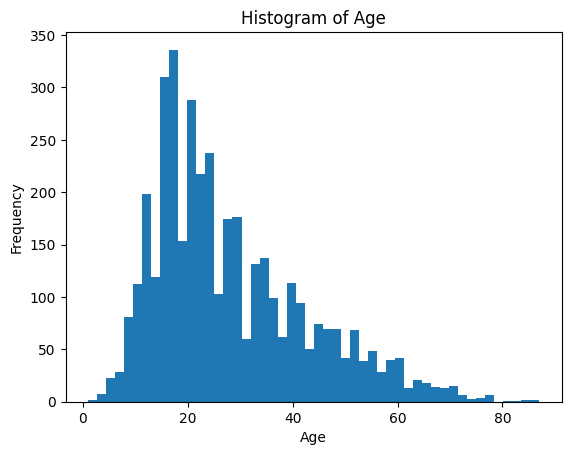

In [167]:
# 4. Clean Age variable
df_cleaned['Age'] = pd.to_numeric(df_cleaned['Age'], errors='coerce') # change from object to numeric
print(df_cleaned['Age'].unique())
print(df_cleaned['Age'].dtype)

# Plot histogram
df_cleaned['Age'].plot.hist(bins=50)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.show()

In [168]:
# 5. Calculating proportion of male victims
print(df_cleaned['Sex'].unique())
# Clean variable so proprtion is taken from data where Sex is known
df_cleaned['Sex'] = df_cleaned['Sex'].str.strip().str.upper()
valid_sex = ['M', 'F', 'M F', 'M X 2']
df_sex = df_cleaned[df_cleaned['Sex'].isin(valid_sex)]
print(df_sex['Sex'].unique())

# Count number of male and female victims and store them
sex_counts = df_sex['Sex'].value_counts()
male_count = int(sex_counts.get('M', 0) + 2*sex_counts.get('M X 2', 0) + sex_counts.get('M F', 0))
female_count = int(sex_counts.get('F', 0) + sex_counts.get('M F', 0))
total_count = male_count + female_count

# Calculate proportion of male victims
male_proportion = male_count / total_count
print('Proportion of male victims:', male_proportion) # aka 87.47%

['F' 'M' 'M ' 'M F' '?' 'F ' nan ' M' 'm' 'lli' 'M x 2' 'N' '.']
['F' 'M' 'M F' 'M X 2']
Proportion of male victims: 0.8746748278500383


In [180]:
# 6. Clean Type Variable
print(df_cleaned['Type'].unique())
df_cleaned['Type'] = df_cleaned['Type'].str.strip().str.upper()
df_cleaned_type = df_cleaned['Type'].replace({
    'PROVOKED' : 'Provoked',
    'UNPROVOKED' : 'Unprovoked',
    'QUESTIONABLE' : 'Unknown',
    'WATERCRAFT' : 'Unknown',
    'SEA DISASTER' : 'Unknown',
    'UNCONFIRMED' : 'Unknown',
    '?' : 'Unknown',
    'UNVERIFIED' : 'Unknown',
    'INVALID' : 'Unknown',
    'UNDER INVESTIGATION' : 'Unknown',
    'BOAT' : 'Unknown',
    })
df_cleaned_type = df_cleaned_type.fillna('Unknown')
print(df_cleaned_type.unique())

print('Proportion of unprovoked attacks:', 5263/df_cleaned_type.value_counts().sum())

['UNPROVOKED' 'PROVOKED' 'QUESTIONABLE' 'WATERCRAFT' 'SEA DISASTER' nan
 '?' 'UNCONFIRMED' 'UNVERIFIED' 'INVALID' 'UNDER INVESTIGATION' 'BOAT']
['Unprovoked' 'Provoked' 'Unknown']
Proportion of unprovoked attacks: 0.7394969790642124


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 2b15ba338fb9b0a16a1608307cec97a47ebb3b49
- **AI tool and model used:** ChatGPT-5.6 Sol

### *Prompts used

1. Revise my code for these questions and help me fill these out :
[inserted the two sections below (changes and suggestions) and then copy and pastied entire code.]

*AI-proposed changes



1. Clean Price by removing commas before converting it to numeric, then calculate the number of missing values directly from the cleaned variable.
2. Preserve missing subject_injury values instead of dropping them, and label them temporarily as Missing when cross-tabulating with force_type so patterns in missingness can be examined.
3. Clean Year with pd.to_numeric(errors='coerce'), examine its minimum and maximum values, and graph yearly attack counts after filtering to 1940 or later.
4. Clean Age with pd.to_numeric(errors='coerce') and let invalid or nonnumeric ages become missing before plotting the histogram.
5. Standardize the Sex variable before calculating the proportion of male victims and exclude values that cannot clearly be interpreted.
6. Clean Type by standardizing capitalization and whitespace, map all categories other than Provoked and Unprovoked to Unknown, and calculate the unprovoked proportion directly instead of hard-coding the count.



*Evaluation of AI suggestions


| Change | Decision | Reason and verification                                                                                                                                                                                          |
| ------ | -------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1      | Accept   | Removing commas is necessary because prices over $999 are stored with commas, which prevents direct numeric conversion. After cleaning, there are 0 missing prices.                                              |
| 2      | Accept   | Missing injury values should not be dropped because the question asks whether missingness is associated with force type. Keeping them showed that about 76.2% of injury values are missing.                      |
| 3      | Accept   | Converting Year to numeric handles invalid values consistently, and filtering to 1940 or later removes clearly unrealistic historical values. The graph shows an overall increase in recorded attacks over time. |
| 4      | Accept   | `errors='coerce'` converts nonnumeric age entries to missing values while keeping valid ages numeric for the histogram.                                                                                          |
| 5      | Modify   | I kept my method of accounting for entries such as `M F` and `M X 2` because those entries contain information about multiple victims rather than simply treating them as missing.                               |
| 6      | Accept   | Standardizing the text first fixes capitalization and spacing differences. Calculating the proportion from the cleaned column is better than manually entering the number of unprovoked attacks.                 |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [181]:
# 1. Cleaning Price Variable

# Load Airbnb data
df = pd.read_csv('./airbnb_hw.csv')

# Look at Price before cleaning
print(df['Price'].unique())
print(df['Price'].dtype)

# Remove commas from prices over $999
df['Price'] = df['Price'].str.replace(',', '', regex=False)

# Convert Price from object to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Check cleaned variable
print(df['Price'].unique())
print(df['Price'].dtype)

# Count missing values
print('Missing values:', df['Price'].isna().sum())

['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1,990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '289' '179' '98' '195' '29' '27' '39'
 '249' '192' '142' '169' '1,000' '131' '138' '113' '122' '329' '101' '475'
 '238' '272' '308' '126' '235' '315' '248' '128' '56' '207' '450' '215'
 '210' '385' '445' '136' '247' '118' '77' '76' '92' '198' '205' '299'
 '222' '245' '104' '153' '349' '114' '320' '292' '226' '420' '500' '325'
 '307' '78' '265' '108' '123' '189' '32' '58' '86' '219' '800' '335' '63'
 '229' '425' '67' '87' '1,200' '158' '650' '234' '310' '695' '400' '166'
 '119' '62' '168' '340' '479' '43' '395' '144' '52' 

I removed the commas from prices over $999 because values such as `1,000` were stored as strings rather than numbers. I then converted the Price variable to numeric using `pd.to_numeric()`, with invalid values converted to missing values. After cleaning, there were **0 missing values** in the Price variable.


In [183]:
# 2. Minnesota Police Use of Force

df = pd.read_csv('./mn_police_use_of_force.csv')

# Look at subject_injury values
print(df['subject_injury'].unique())
print(df['subject_injury'].value_counts(dropna=False))

# Clean whitespace
df['subject_injury'] = df['subject_injury'].str.strip()

# Change blank strings to missing
df['subject_injury'] = df['subject_injury'].replace('', np.nan)

# Count and proportion missing
missing_count = df['subject_injury'].isna().sum()
missing_prop = df['subject_injury'].isna().mean()

print('Missing values:', missing_count)
print('Proportion missing:', missing_prop)
print('Percent missing:', missing_prop * 100)

# Make a temporary variable so missing values appear in cross-tab
df['subject_injury_cross'] = df['subject_injury'].fillna('Missing')

# Cross-tabulate injury and force type
cross_tab = pd.crosstab(
    df['subject_injury_cross'],
    df['force_type']
)

print(cross_tab)

# Proportions within each force type
cross_tab_prop = pd.crosstab(
    df['subject_injury_cross'],
    df['force_type'],
    normalize='columns'
)

print(cross_tab_prop)

[nan 'No' 'Yes']
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
Missing values: 9848
Proportion missing: 0.7619342359767892
Percent missing: 76.19342359767892
force_type            Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_cross                                                    
Missing                   2          7051               1421        0   
No                        0          1093                131        2   
Yes                       2          1286                 41        0   

force_type            Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury_cross                                                      
Missing                              27                 74           87   
No                                   33                 34            0   
Yes                                  44                 40            0   

force_type            Less Lethal Projectile  Maximal Restraint Techn

There were **9,848 missing values**, meaning about **76.2%** of the `subject_injury` observations were missing. This is a concern because more than three-fourths of the observations do not contain injury information, so conclusions about injuries may not represent the full dataset.

The cross-tabulation also suggests that the missing data are not evenly distributed across force types. **Bodily Force, Taser, and Chemical Irritant** cases had especially high proportions of missing injury information, with at least 70% missing. This suggests that whether injury was recorded may be related to the type of force used.

In [191]:
# 1. Open shark attack file
df = pd.read_excel('./GSAF5.xls')

print(df.head())
print(df.shape)

# 2. Drop columns that do not contain useful data

# Keep the meaningful columns from Date through Source
df_cleaned = df.loc[:, 'Date':'Source'].copy()

print(df_cleaned.head())
print(df_cleaned.columns)
print(df_cleaned.shape)

           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age  ...                    Species   \
0   Unknown Female   F   ?  ...                

[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914. 1913. 1912. 1911. 1910. 1909.
 1908. 1907. 1906. 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1897.
 1896. 1895. 1894. 1893. 1892. 1891. 1890. 1889. 1888. 1887. 1886. 1885.
 1884. 1883. 1882. 1881. 1880. 1879. 1878. 1877. 1876. 1875. 1874. 1873.
 1872. 1871. 1870. 1869. 1868. 1867. 1866. 1865. 18

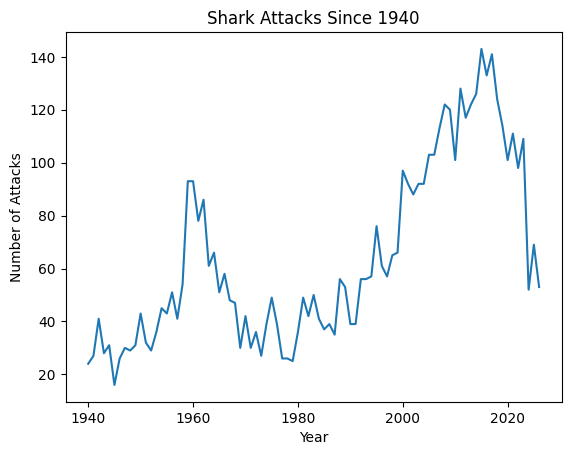

In [187]:
# 3. Clean Year variable

print(df_cleaned['Year'].unique())

# Convert Year to numeric
df_cleaned['Year'] = pd.to_numeric(
    df_cleaned['Year'],
    errors='coerce'
)

print('Minimum year:', df_cleaned['Year'].min())
print('Maximum year:', df_cleaned['Year'].max())

# Focus on attacks since 1940
df_since1940 = df_cleaned[df_cleaned['Year'] >= 1940].copy()

# Count attacks per year
attacks_per_year = (
    df_since1940['Year']
    .value_counts()
    .sort_index()
)

# Plot attacks over time
attacks_per_year.plot()

plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Shark Attacks Since 1940')
plt.show()

**3. Year:** The Year variable contained values ranging from **0 to 2026**, including clearly unusual values such as 5, 77, and 1000. I converted the variable to numeric and focused on attacks from 1940 onward. The graph shows that recorded shark attacks **generally increase over time**, particularly from around 1980 through the 2010s, although there is variation from year to year.

**4. Age:** I converted Age to numeric using `errors='coerce'`, so entries that could not be interpreted as a single numeric age were treated as missing. The histogram shows the distribution of victim ages among the observations with valid numeric ages.

**5. Sex:** After cleaning the Sex variable and using observations where sex could be interpreted, approximately **87.47% of victims were male**.

**6. Type:** I standardized capitalization and whitespace and grouped all classifications other than Provoked and Unprovoked into Unknown. After cleaning, approximately **73.95% of attacks were Unprovoked**.


[nan 43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 19. 11. 20. 38. 39. 16. 22.
 55. 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85. 18. 66.
 37. 42. 45. 30. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65. 64.
 32. 10. 62. 52. 44. 47. 59. 50. 34. 77. 73. 67.  6. 53. 51. 75. 70.  4.
 74.  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.]
float64


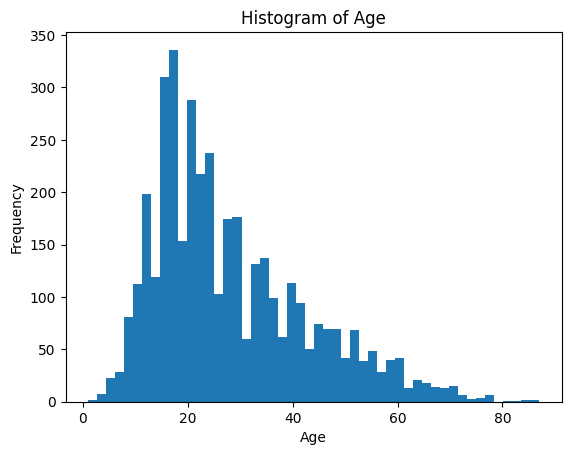

In [196]:
# 4. Clean Age variable
df_cleaned['Age'] = pd.to_numeric(df_cleaned['Age'], errors='coerce') # change from object to numeric
print(df_cleaned['Age'].unique())
print(df_cleaned['Age'].dtype)

# Plot histogram
df_cleaned['Age'].plot.hist(bins=50)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.show()

In [189]:
# 5. Calculate proportion of male victims

# Standardize formatting
df_cleaned['Sex'] = df_cleaned['Sex'].str.strip().str.upper()

print(df_cleaned['Sex'].unique())

# Count the recognizable sex values
sex_counts = df_cleaned['Sex'].value_counts()

# Include mixed/multiple-victim observations
male_count = (
    sex_counts.get('M', 0)
    + sex_counts.get('M F', 0)
    + 2 * sex_counts.get('M X 2', 0)
)

female_count = (
    sex_counts.get('F', 0)
    + sex_counts.get('M F', 0)
)

# Total victims with identifiable sex
total_count = male_count + female_count

male_proportion = male_count / total_count

print('Proportion of male victims:', male_proportion)
print('Percent male:', male_proportion * 100)

['F' 'M' 'M F' '?' nan 'LLI' 'M X 2' 'N' '.']
Proportion of male victims: 0.8746748278500383
Percent male: 87.46748278500382


In [190]:
# 6. Clean Type variable

print(df_cleaned['Type'].unique())

# Standardize capitalization and spaces
df_cleaned['Type'] = (
    df_cleaned['Type']
    .str.strip()
    .str.upper()
)

# Keep Provoked and Unprovoked; everything else becomes Unknown
df_cleaned['Type_clean'] = df_cleaned['Type'].replace({
    'PROVOKED': 'Provoked',
    'UNPROVOKED': 'Unprovoked'
})

df_cleaned.loc[
    ~df_cleaned['Type_clean'].isin(['Provoked', 'Unprovoked']),
    'Type_clean'
] = 'Unknown'

print(df_cleaned['Type_clean'].unique())
print(df_cleaned['Type_clean'].value_counts())

# Calculate proportion automatically
unprovoked_prop = (
    df_cleaned['Type_clean'].eq('Unprovoked').mean()
)

print('Proportion of unprovoked attacks:', unprovoked_prop)
print('Percent unprovoked:', unprovoked_prop * 100)

['Unprovoked' 'Provoked' 'Questionable' 'UNprovoked' 'unprovoked'
 ' Provoked' 'Watercraft' 'Sea Disaster' nan '?' 'Unconfirmed'
 'Unverified' 'Invalid' 'Under investigation' 'Boat']
['Unprovoked' 'Provoked' 'Unknown']
Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64
Proportion of unprovoked attacks: 0.7394969790642124
Percent unprovoked: 73.94969790642124


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements the AI suggested was making my code more direct and making sure it actually answered the questions thoroughly. For example, it suggested removing the commas from the Airbnb price variable before converting it to numeric which kept the missing values in the subject_injury column so I could see patterns in the cross-tab. It also suggested caclulating proportions directly from the data instead of self-coding values like the number of unprovoked attacks.
One limitation was that some of the AI suggestions were more complicated than needed. For the Sex variable, I chose to slightly modify its suggestion becuase values like 'M F' and 'M X 2' represent multiple invividuals so I wanted to account for those properly. Another limitation was that AI couldn't quite fix some parts of my code. I noticed the Age question still wasn't fully resolved just because of how messy the code was.
I verified the final solutions by printing unique values before and after cleaning, checked data types, counted missing values, and reviewed the value counts and cross-tabs. My big remaining concern is that some variables in the shark attack dataset are messy and inconsistently recorded so certain cleaning choices I made are based are assumptions rather than it being perfectly standardized data.